## Ambiente

In [1]:
# ## OSX
# !pip install torch==2.11.0 torchvision==0.26.0 torchaudio==2.11.0
#
# ## WINDOWS / LINUX
#
# ## AMD RADEON
# # ROCM 7.2 (Linux only)
# !pip install torch==2.11.0 torchvision==0.26.0 torchaudio==2.11.0 --index-url https://download.pytorch.org/whl/rocm7.2
#
# # Nvidia
# # CUDA 12.6
# !pip install torch==2.11.0 torchvision==0.26.0 torchaudio==2.11.0 --index-url https://download.pytorch.org/whl/cu126
# # CUDA 12.8
# !pip install torch==2.11.0 torchvision==0.26.0 torchaudio==2.11.0 --index-url https://download.pytorch.org/whl/cu128
# # CUDA 13.0
# !pip install torch==2.11.0 torchvision==0.26.0 torchaudio==2.11.0 --index-url https://download.pytorch.org/whl/cu130
# # CPU only
# !pip install torch==2.11.0 torchvision==0.26.0 torchaudio==2.11.0 --index-url https://download.pytorch.org/whl/cpu

In [3]:
K_VEC_SIZE = 35
CHUNK_SIZE = 512
CHUNK_OVERLAP = 50
BATCH_SIZE = 32
MAX_NEW_TOKENS = 512
DO_SAMPLE = True
TEMPERATURE = 0.2

In [4]:
import torch
import pandas as pd
from pathlib import Path

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else
                      ("xpu" if torch.xpu.is_available() else "cpu"))
device

device(type='cuda')

In [6]:
if device.type == 'cuda':
    print(f'CUDA version: {torch.version.cuda}')

CUDA version: 13.0


In [7]:
DATASET_DIR = 'dataset'
DATASET_FILENAMES = ['Anvisa_Alertas_2026-01-01_2026-06-19.csv', 'Anvisa_Alertas_MEDICAMENTOS.csv']
LOG_DIR = 'logs'
ROOT_DIR = Path().resolve().__str__()
DATASET_PATH = ROOT_DIR + '/' + DATASET_DIR
DATASET_FILEPATHS = [Path(DATASET_DIR + '/' + file + '/') for file in DATASET_FILENAMES]
Path.mkdir(Path(DATASET_PATH), parents=True, exist_ok=True)
LOG_PATH = Path(ROOT_DIR + '/' + LOG_DIR)
Path.mkdir(LOG_PATH, exist_ok=True)

In [8]:
df_collection = [pd.read_csv(DATASET_FILEPATH) for DATASET_FILEPATH in DATASET_FILEPATHS]

In [9]:
df_collection[0]

,titulo,data,url,content
0,Alerta 5265 (Tecnovigilância) - Comunicado da ...,16/06/2026,http://antigo.anvisa.gov.br/informacoes-tecnic...,Área: GGMON Número: 5265 Ano: 2026 ...
1,Alerta 5264 (Tecnovigilância) - Comunicado da ...,16/06/2026,http://antigo.anvisa.gov.br/informacoes-tecnic...,Área: GGMON Número: 5264 Ano: 2026 ...
2,Alerta 5263 (Tecnovigilância) - Comunicado da ...,16/06/2026,http://antigo.anvisa.gov.br/informacoes-tecnic...,Área: GGMON Número: 5263 Ano: 2026 ...
3,Alerta 5262 (Tecnovigilância) - Comunicado da ...,16/06/2026,http://antigo.anvisa.gov.br/informacoes-tecnic...,Área: GGMON Número: 5262 Ano: 2026 ...
4,Alerta 5261 (Tecnovigilância) - Comunicado da ...,16/06/2026,http://antigo.anvisa.gov.br/informacoes-tecnic...,Área: GGMON Número: 5261 Ano: 2026 ...
...,...,...,...,...
3514,Alerta 1789 Atualizado (Tecnovigilância) - GE ...,13/01/2016,http://antigo.anvisa.gov.br/informacoes-tecnic...,Área: GGMON Número: 1789 Ano: 2016 ...
3515,Alerta 1788,12/01/2016,http://antigo.anvisa.gov.br/informacoes-tecnic...,Área: GGMON Número: 1788 Ano: 2016 ...
3516,Alerta 1787,12/01/2016,http://antigo.anvisa.gov.br/informacoes-tecnic...,Área: GGMON Número: 1787 Ano: 2016 ...
3517,Alerta 1780,06/01/2016,http://antigo.anvisa.gov.br/informacoes-tecnic...,Área: GGMON Número: 1780 Ano: 2016 ...


In [10]:
df_collection[1]

,medicamento,situacao,data_Vencimento_Registro,categoria_Regulatoria_Descricao,tipo_Autorizacao,razao_Social,cnpj_Formatado,numero_Processo_Formatado
0,IROSÊ,Ativo,2033-08-01,Similar,REGISTRADO,ALTHAIA S.A. INDUSTRIA FARMACEUTICA,48.344.725/0007-19,25351.305631/2023-68
1,SOLIQUA,Ativo,2027-07-01,Biológico,REGISTRADO,SANOFI MEDLEY FARMACÊUTICA LTDA.,10.588.595/0010-92,25351.411883/2019-49
2,ARCALION,Ativo,2026-12-01,Novo,REGISTRADO,LABORATÓRIOS SERVIER DO BRASIL LTDA,42.374.207/0001-76,25992.016621/74
3,CLORIDRATO DE TERBINAFINA,Ativo,2027-10-01,Genérico,REGISTRADO,EMS S/A,57.507.378/0003-65,25351.028936/01-28
4,COSARTAN ALP,Ativo,2028-11-01,Similar,REGISTRADO,GERMED FARMACEUTICA LTDA,45.992.062/0001-65,25351.447535/2012-63
...,...,...,...,...,...,...,...,...
43225,BECLORT,Inativo,2015-12-01,Similar,REGISTRADO,GLENMARK FARMACÊUTICA LTDA,44.363.661/0001-57,25351.142107/2005-98
43226,CAPTOPRIL,Inativo,2016-02-01,Genérico,REGISTRADO,BIOSINTÉTICA FARMACÊUTICA LTDA,53.162.095/0001-06,25351.030163/00-96
43227,FENOPROFENO CALCICO,Inativo,2002-09-01,Similar,REGISTRADO,ATIVUS FARMACÊUTICA LTDA,64.088.172/0001-41,25000.026073/96-50
43228,KITNOS,Inativo,2016-10-01,NaN,REGISTRADO,LABORATÓRIOS PFIZER LTDA,46.070.868/0036-99,25351.026061/2004-80


## Embedding

In [11]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=device)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

C:\Users\Renata\miniconda3\envs\pd__llm\Lib\site-packages\torch\nn\modules\module.py:1370: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:39.)
  return t.to(


In [12]:
def chunk_text(docs, chunk_size=500):
    from langchain_text_splitters import RecursiveCharacterTextSplitter
    splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=CHUNK_OVERLAP)
    chunks = splitter.split_text("\n\n".join(docs))
    return chunks

In [13]:
docs = []
for i, row in df_collection[1].iterrows():
    doc = \
f"""
Medicamento: {row['medicamento']}
Situação atual: {row['situacao']}
Data de Vencimento do Registro: {row['data_Vencimento_Registro']}
Categoria Regulatória: {row['categoria_Regulatoria_Descricao']}
Tipo autorização: {row['tipo_Autorizacao']}
Empresa: {row['razao_Social']}
CNPJ: {row['cnpj_Formatado']}
Número do processo: {row['numero_Processo_Formatado']}
======================================================================
"""
    docs.append(doc)

In [14]:
docs.extend(df_collection[0]['content'].to_list())

In [15]:
chunked = chunk_text(docs, CHUNK_SIZE)

In [16]:
del docs, df_collection
torch.cuda.empty_cache()

In [17]:
embeddings = embedder.encode(chunked, chunk_size=CHUNK_SIZE, batch_size=BATCH_SIZE, show_progress_bar=True, convert_to_numpy=True)

Batches:   0%|          | 0/2466 [00:00<?, ?it/s]

In [18]:
embeddings.shape

(78889, 384)

## FAISS

In [19]:
import faiss
import numpy as np

dimension = embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)
index.add(np.array(embeddings, dtype=np.float16))

### Busca contexto

In [20]:
# query = "Quais empresas são as mais mencionadas?"

In [21]:
n=[5,10,20,25]

query_embedding = embedder.encode(
    [query],
    normalize_embeddings=True
)

scores, ids = index.search(
    np.array(query_embedding, dtype=np.float32),
    k=K_VEC_SIZE
)

context_chunks = [chunked[i] for i in ids[0]]

context = "\n\n".join(context_chunks)

del context_chunks, chunked

## LLM

In [22]:
model_id = "mistralai/Ministral-3-3B-Instruct-2512-BF16"
# model_id = "mistralai/Ministral-3-8B-Instruct-2512-BF16"

In [23]:
from transformers import Mistral3ForConditionalGeneration, AutoTokenizer, AutoConfig, AutoModelForCausalLM
from transformers.tokenization_mistral_common import MistralTokenizer, MistralCommonBackend
from transformers.utils.quantization_config import FineGrainedFP8Config, BitsAndBytesConfig

model = Mistral3ForConditionalGeneration.from_pretrained(model_id, device_map=device, dtype=torch.float16)

tokenizer = AutoTokenizer.from_pretrained(
    model_id,
    use_fast=True,
    trust_remote_code=True
)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/458 [00:00<?, ?it/s]

In [24]:
task=[
    "Você é um assistente que responde apenas com base no contexto.",
    "Priorize a extração de data, motivo e número do alerta ou qualquer outro número ou código que embase a citação / nome da empresa e CNPJ.",
    "Priorize alertas mais recentes."
    "Sempre exiba o CNPJ quando citar uma empresa. Se o CNPJ não estiver no contexto, não o invente.",
    "Sempre mencione o número do alerta/processo/etc quando descrever ou realizar alguma afirmação.",
    "Use a formatação dd/mm/aaaa para datas.",
    "Se a resposta não estiver no contexto, declare que não sabe. Não invente informação."
    "Não cite o contexto."
]

In [25]:
def build_message(task = None, context = None, query = None):
    return \
        [
            {
                "role": "system",
                "content": " | ".join(map(str, task)) if task is not None else "",
            },
            {
                "role": "user",
                "content": f"Contexto: {context}",
            },
            {
                "role": "user",
                "content": f"Pergunta: {query}",
            }
        ]


In [26]:
messages = build_message(task, context, query)

inputs = tokenizer.apply_chat_template(
    messages,
    return_tensors="pt",
    add_generation_prompt=True,
    skip_special_tokens=True,
    # truncation=True,

).to(model.device)

del messages

In [27]:
print(f"Input Tokens: {inputs["input_ids"].shape}")

Input Tokens: torch.Size([1, 5006])


In [28]:
def call_model_generate(args: dict):
    from time import strftime, time, gmtime
    torch.cuda.empty_cache()
    start = time()
    outputs = (
        model.generate(
        **args['input_ids'],
        max_new_tokens=args['max_new_tokens'],
        max_length=args['max_length'],
        do_sample=args['do_sample'],
        temperature=args['temperature'],
    ))
    end = time()
    exec_time = strftime('%Hh %Mm %Ss', gmtime(end-start))
    return outputs, exec_time

In [29]:
args = dict({
    'input_ids': inputs,
    'max_new_tokens': MAX_NEW_TOKENS,
    'max_length': None,
    'do_sample': DO_SAMPLE,
    'temperature': TEMPERATURE,
})

outputs, exec_time = call_model_generate(args)

In [30]:
answer = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
).split(query)[1]

In [31]:
import time

with open(LOG_PATH.absolute().__str__() + '\\log_' + time.strftime('%Y%m%d%H%M%S', time.localtime()) + '_k=' + str(K_VEC_SIZE) + '.txt', 'w', encoding='utf-8') as log:
    print('******************************************************************', file=log)
    print('Parametros:', file=log)
    print(f'k_vector_size = {K_VEC_SIZE}', file=log)
    print(f'batch_size = {BATCH_SIZE}', file=log)
    print(f'chunk_size = {CHUNK_SIZE}', file=log)
    print(f'chunk_overlay = {CHUNK_OVERLAP}', file=log)
    print(f'do_sample = {DO_SAMPLE}', file=log)
    print(f'temperature = {TEMPERATURE}', file=log)
    print(f'Execution time = {exec_time}', file=log)
    print(f'Device = {device.type}', file=log)
    print('******************************************************************', file=log)
    print(f'Pergunta: \n{query}', end='\n\n', file=log)
    print(f'Responsta:\n{answer}', file=log)
    log.close()

In [78]:
from IPython.display import Markdown
Markdown(answer.split(query)[1])

No contexto fornecido, as seguintes medicações foram mencionadas em alertas da **Anvisa**:

1. **Clobutinol** (Alerta não especificado no número, mas relacionado a notificações de eventos adversos no sistema VigiMed).
   - **CNPJ da empresa detentora do registro**: 18.747.319/0001-40 (Total Medical Brasil).

2. **Finasterida e Dutasterida** (Alerta **3631**).
   - **CNPJ da empresa detentora do registro**: 08.546.929/0001-22 (Carestream Health).

3. **Fosfoetanolamina** (Não citado em alerta específico, mas mencionado como substância sem aprovação da Anvisa).

4. **Hidroxicloroquina e Cloroquina** (Alerta relacionado à **Portaria da Anvisa** sobre controle de produtos para COVID-19, mas não especificado número de alerta).

5. **Medicamentos para disfunção erétil** (como sildenafila, vardenafila e tadalafila) – mencionados em estudos e alertas sobre uso recreativo (sem número de alerta específico).

6. **Qdenga** (Vacina contra dengue) – Alertas relacionados à vigilância sanitária, mas não citado com número específico.

7. **Medicamentos com grafia ou som semelhantes** (exemplo: *Curcumina* e extratos com alto teor de curcumina) – não citado em alerta formal, mas mencionado em contexto de riscos à saúde.

---
**Nota**: O alerta mais recente específico para **finasterida/dutasterida** é o **3631**. Para clobutinol, não há número de alerta explicitado, mas está associado a notificações no VigiMed.

<Axes: xlabel='K', ylabel='Tempo'>

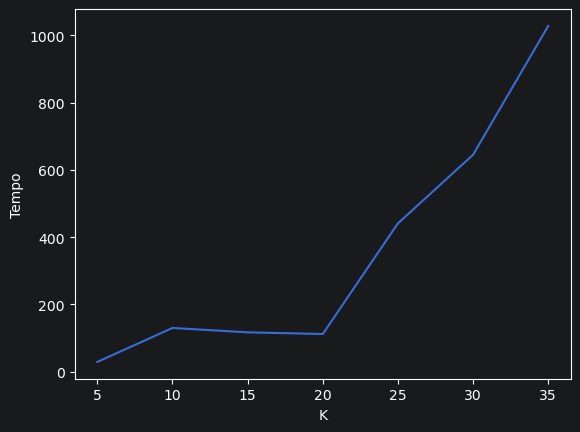

In [76]:
X_t_Y_k = pd.DataFrame(data={
    'Tempo': [29, 130, 117, 112, 441, 645, 1028],
    'K': [5, 10, 15, 20, 25, 30, 35],
})

import seaborn as sns

sns.lineplot(data=X_t_Y_k, y='Tempo', x='K',)